# **DATA ANALYSIS PROJECT**
## Case : Telco Customer Churn

# **IMPORT LIBRARY**

In [ ]:
# Library

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from scipy.stats import shapiro                         # Uji Normalitas
from scipy.stats import ttest_1samp                     # One Sample T Test
from scipy.stats import ttest_ind                       # Independent T Test
from scipy.stats import ttest_rel                       # Paired T Test
from scipy.stats import f_oneway                        # ANOVA
from scipy.stats import wilcoxon                        # Wilcoxon One Way dan Paired
from scipy.stats import mannwhitneyu                    # Mann Whitney U Test
from scipy.stats import kruskal                         # Kruskal Wallis

from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import chi2_contingency

# **BUSINESS UNDERSTANDING**

## **1. BACKGROUND**

Perusahaan telekomunikasi yang akan dibahas dalam kasus ini berlatar belakang **di tahun 2015** dan berlokasi di **California, Amerika**. (*jika merujuk pada data telco customer churn dari IBM yang telah diupdate*).

Dengan bermodalkan *subcription based income*, perusahaan telekomunikasi menawarkan metode kontrak perbulan, 1 tahunan, dan 2 tahunan. Produk yang ditawarkan dibagi menjadi 2 produk utama yaitu layanan *landline* telepon dan layanan internet yang selanjutnya memiliki produk turunan masing-masing.

Data yang diberikan akan digunakan untuk menganalisa hubungan demografi dengan tingkat *churn* pelanggan. Tingkat *churn* yang terbilang cukup tinggi pada perusahaan telco berada di *10 - 15%* (Forbes 2015 Industry Review).

Setelah mendapatkan evaluasi dari dataset ini, diharapkan dapat berguna untuk divisi **Sales & Marketing**, terlebih lagi untuk **Commercial / Marketing Director** sebagai pengambil keputusan dalam mengantisipasi pelanggan yang memiliki riwayat demografi akan *churn* sebagai pertimbangan dalam pengambilan langkah bisnis.

## **2. PROBLEM STATEMENT**

Keberadaan **pelanggan** sangat mempengaruhi **Revenue** dan **Profit** yang dapat diperoleh suatu perusahaan. **Pelanggan tetap** *(loyal)* umumnya akan **memberikan Revenue dan Profit yang lebih besar** dibandingkan pelanggan baru. Hal ini dikarenakan dalam mencari atau **menarik pelanggan baru**, perusahaan perlu mengeluarkan **modal yang besar untuk pemasarannya**. Oleh karena itu, setiap perusahaan selalu berlomba-lomba untuk mempertahankan pelanggannya dan mencegah memiliki ***churn rate*** yang tinggi.

**Masalah Utama**

`Mengetahui tingkat churn perusahaan dan mencari penyebab-penyebab churn`

**Masalah Turunan**

1. **Tingkat *Churn***: Apakah tingkat *churn* yang dimiliki perusahaan sudah sesuai dengan standar perusahaan telco atau berada dalam kategori berbahaya.
2. **Korelasi antara Tingkat *Churn* dengan Demografi**: Apakah demografi pelanggan mempengaruhi kemungkinan pelanggan untuk *churn*.
3. **Korelasi antara Tenure dengan Produk**: Apakah lamanya pelanggan dengan perusahaan mempengaruhi ketertarikan pelanggan dalam menggunakan produk perusahaan.
4. **Pengaruh Metode Pembayaran dan Kontrak layanan terhadap *Churn***: Apakah jenis kontrak atau metode pembayaran mempengaruhi keputusan pelanggan untuk *churn*.

## **3. GOALS**

Goal Bisnis yang ingin dicapai :

- **Demografi Pelanggan yang Churn**: Mengidentifikasi demografi pelanggan *churn* dan penyebab pelanggan tersebut *churn*.
- **Penurunan Tingkat Churn**: Memberikan ide yang dapat menurunkan tingkat churn sekarang menjadi lebih baik.
- **Produk Dengan Performa Buruk**: Mengidentifikasi produk yang memiliki *revenue loss* atau tingkat *churn* tinggi.
- **Metode Pembayaran dan Kontrak Layanan Buruk**: Mengidentifikasi metode pembayaran dan tipe kontrak yang sering menyebabkan *churn* pada pelanggan.

## **4. ANALYTICAL APPROACH**

Pendekatan analitik dimulai dengan proses **Exploratory Data Analysis (EDA)** sebagai fondasi utama untuk mencari korelasi dan temuan yang akan membantu stakeholder dalam menghadapi masalah dan menggapai goals yang telah ditentukan.

# **DATA UNDERSTANDING**

## **1. DESKRIPSI DATASET**

- Sumber dataset: [IBM Sample Dataset for Cognos Analytics and Predictive Modeling Software](https://www.kaggle.com/datasets/blastchar/telco-customer-churn/data)
- Jumlah Baris : 7,043 *(Customers)*
- Jumlah Kolom: 21 *(Features)*
- Periode : 2015

| Nama Kolom | Tipe Data | Deskripsi |
| :--- | :--- | :--- |
| **`customerID`** | Object | Kode unik customer. |
| **`gender`** | Object | Jenis kelamin customer (male/female). |
| **`SeniorCitizen`** | Integer -> Object | Customer masuk kategori lansia (*senior citizen*) (1/0 -> yes/no). |
| **`Partner`** | Object | Customer memiliki pasangan hidup (yes/no). |
| **`Dependents`** | Object | Customer memiliki tanggungan (anak, orang tua yang dibiayai) (yes/no). |
| **`tenure`** | Integer | Berapa lama customer telah menggunakan jasa perusahaan (dalam bulan). |
| **`PhoneService`** | Object | Apakah customer memiliki layanan telefon? (yes/no). |
| **`MultipleLines`** | Object | Apakah customer memiliki banyak line telefon (yes, no, no phone service). |
| **`InternetService`** | Object | Customer internet service provider (DSL, fiber optic, no). |
| **`OnlineSecurity`** | Object | Apakah customer memiliki layanan pengamanan online (yes, no, no internet service). |
| **`OnlineBackup`** | Object | Apakah customer memiliki layanan backup online (yes, no, no internet service). |
| **`DeviceProtection`** | Object | Apakah customer memiliki layanan pengamanan device (yes, no, no internet service). |
| **`TechSupport`** | Object | Apakah customer memiliki layananan tech support (yes, no, no internet service). |
| **`StreamingTV`** | Object | Apakah customer memiliki layananan TV streaming (yes, no, no internet service). |
| **`StreamingMovies`** | Object | Apakah customer memiliki layanan movie streaming (yes, no, no internet service). |
| **`Contract`** | Object | Jenis kontrak yang diambil customer (month-to-month, one year, two year). |
| **`PaperlessBilling`** | Object | Apakah customer memilih layanan paperless billing (yes, no). |
| **`PaymentMethod`** | Object | Metode pembayaran customer (electronic check, mailed check, bank transfer(automatic), credit card). |
| **`MonthlyCharges`** | Float | Jumlah yang ditagihkan ke customer perbulannya. |
| **`TotalCharges`** | Object -> Integer | Jumlah tagihan customer. |
| **`Churn`** | Object | Apakah customer berhenti berlangganan (yes/no). |

Notes :
- Senior Citizen : Lansia di atas 55 tahun
- Dependents : Memiliki tanggungan yang tidak berpenghasilan (orang tua, anak)

## **2. DATASET PREVIEW**


In [ ]:
data = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [ ]:
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
data.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


# **DATA CLEANING**


### Data Cleaning: TotalCharges

In [ ]:
# Perubahan tipe data TotalCharge dari object ke integer.

data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')

In [ ]:
data.isna().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
# Setelah tipe data disesuaikan, terdapat nilai kosong pada kolom TotalCharges. Nilai kosong diganti dengan agar kolom dapat digunakan

data['TotalCharges'].fillna(0, inplace=True)
data.isna().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
# Melihat data kosong yang telah diubah menjadi nilai 0

data['TotalCharges'][data['TotalCharges'] == 0]

,TotalCharges
488,0.0
753,0.0
936,0.0
1082,0.0
1340,0.0
3331,0.0
3826,0.0
4380,0.0
5218,0.0
6670,0.0


### Data Cleaning: SeniorCitizen



In [ ]:
# Perubahan tipe data SeniorCitizen dari angka menjadi teks

data['SeniorCitizen'] = data['SeniorCitizen'].astype(str)
print(data['SeniorCitizen'].dtypes)

object


In [ ]:
# Perubahan isi data SeniorCitizen (0 menjadi No, 1 menjadi Yes) untuk mempermudah visualisasi dan penyeragaman data

data['SeniorCitizen'].replace(["0", "1"], ["No", "Yes"], inplace=True)
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### Data Cleaning: Check Duplicate



In [ ]:
# Melihat apakah ada duplikasi data
data.duplicated().sum()

np.int64(0)

### Data Cleaning: Check Data dengan TotalCharges 0

In [ ]:
# Pengecekan data dengan TotalCharges 0 tetapi terdapat MonthlyCharge. Data ini terbentuk karena customer sudah memiliki tagihan berjalan, tetapi belum tertagih jadi data dianggap valid.

data[["customerID", "MonthlyCharges", "TotalCharges", "Churn"]][data['TotalCharges'] == 0]

,customerID,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,52.55,0.0,No
753,3115-CZMZD,20.25,0.0,No
936,5709-LVOEQ,80.85,0.0,No
1082,4367-NUYAO,25.75,0.0,No
1340,1371-DWPAZ,56.05,0.0,No
3331,7644-OMVMY,19.85,0.0,No
3826,3213-VVOLG,25.35,0.0,No
4380,2520-SGTTA,20.00,0.0,No
5218,2923-ARZLG,19.70,0.0,No
6670,4075-WKNIU,73.35,0.0,No


### Data Cleaning: Pengecekan input unique dari setiap kolom

In [ ]:
# Melihat isi tiap kolom kategori untuk mengecek kemungkinan adanya typo

kolom_cek = ["gender", "SeniorCitizen", "Partner", "Dependents", "PhoneService", "MultipleLines", "OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies", "Contract", "PaperlessBilling", "PaymentMethod", "Churn"]

for i in kolom_cek :
    print(f"{i} = {data[i].unique()}")

gender = ['Female' 'Male']
SeniorCitizen = ['No' 'Yes']
Partner = ['Yes' 'No']
Dependents = ['No' 'Yes']
PhoneService = ['No' 'Yes']
MultipleLines = ['No phone service' 'No' 'Yes']
OnlineSecurity = ['No' 'Yes' 'No internet service']
OnlineBackup = ['Yes' 'No' 'No internet service']
DeviceProtection = ['No' 'Yes' 'No internet service']
TechSupport = ['No' 'Yes' 'No internet service']
StreamingTV = ['No' 'Yes' 'No internet service']
StreamingMovies = ['No' 'Yes' 'No internet service']
Contract = ['Month-to-month' 'One year' 'Two year']
PaperlessBilling = ['Yes' 'No']
PaymentMethod = ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
Churn = ['No' 'Yes']


# **DATA ANALYSIS**

### Data Analysis: Melakukan analisa awal dari keseluruhan data

In [ ]:
# Melihat statistik dari kolom-kolom numerik

data.describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304
std,24.559481,30.090047,2266.794470
min,0.000000,18.250000,0.000000
25%,9.000000,35.500000,398.550000
50%,29.000000,70.350000,1394.550000
75%,55.000000,89.850000,3786.600000
max,72.000000,118.750000,8684.800000


In [ ]:
# Melihat statistik dari kolom-kolom kategorik

data.describe(include='object')

,customerID,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,2
top,3186-AJIEK,Male,No,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,No
freq,1,3555,5901,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,5174


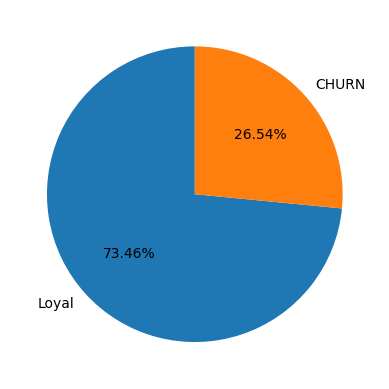

In [ ]:
# Visualisasi CHURN Rate

label_pie = ["Loyal", "CHURN"]
y = [data["Churn"][data["Churn"] == "No"].count(), data["Churn"][data["Churn"] == "Yes"].count()]

plt.pie(y, labels = label_pie, autopct='%1.2f%%', startangle=90)
plt.show()

**Hasil Yang Ditemukan**

- Mayoritas pelanggan **BUKAN SENIOR CITIZEN**
- Mayoritas pelanggan **menggunakan PhoneService**
- Mayoritas pelanggan **LOYAL** (tidak CHURN)
- **CHURN Rate adalah 26.54%** dari total pelanggan pada data.
- Nilai **minimal 0** pada kolom `tenure` dan `TotalCharges` menunjukkan data pelanggan baru



### Data Analysis: Data CHURN Pelanggan

In [ ]:
# Menampilkan data pelanggan yang CHURN

demochurn = data[data['Churn'] == "Yes"]
demochurn.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,No,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes
8,7892-POOKP,Female,No,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
13,0280-XJGEX,Male,No,No,No,49,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,Yes


In [ ]:
# Melihat statistik dari kolom-kolom numerik DATA CHURN

demochurn.describe()

,tenure,MonthlyCharges,TotalCharges
count,1869.000000,1869.000000,1869.000000
mean,17.979133,74.441332,1531.796094
std,19.531123,24.666053,1890.822994
min,1.000000,18.850000,18.850000
25%,2.000000,56.150000,134.500000
50%,10.000000,79.650000,703.550000
75%,29.000000,94.200000,2331.300000
max,72.000000,118.350000,8684.800000


In [ ]:
# Melihat statistik dari kolom-kolom kategorik DATA CHURN

demochurn.describe(include="object")

,customerID,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
count,1869,1869,1869,1869,1869,1869,1869,1869,1869,1869,1869,1869,1869,1869,1869,1869,1869,1869
unique,1869,2,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,1
top,8361-LTMKD,Female,No,No,No,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,Yes
freq,1,939,1393,1200,1543,1699,850,1297,1461,1233,1211,1446,942,938,1655,1400,1071,1869


In [ ]:
# Melakukan perbandingan gender pelanggan yang churn

pd.crosstab(data['gender'], data['Churn'], normalize='index') * 100

Churn,No,Yes
gender,,
Female,73.079128,26.920872
Male,73.839662,26.160338


In [ ]:
# Melihat PaymentMethod pelanggan yang CHURN berdasarkan umur
payment_cust = demochurn[['PaymentMethod', "SeniorCitizen", "customerID"]].groupby("PaymentMethod").agg(
    Total_Pelanggan = ("customerID", "count"),
    Pelanggan_Muda = ("SeniorCitizen", lambda x: (x=="No").sum()),
    Pelanggan_Senior = ("SeniorCitizen", lambda x: (x=="Yes").sum())
).sort_values("Total_Pelanggan", ascending=False).reset_index()

display(payment_cust)

,PaymentMethod,Total_Pelanggan,Pelanggan_Muda,Pelanggan_Senior
0,Electronic check,1071,754,317
1,Mailed check,308,264,44
2,Bank transfer (automatic),258,205,53
3,Credit card (automatic),232,170,62


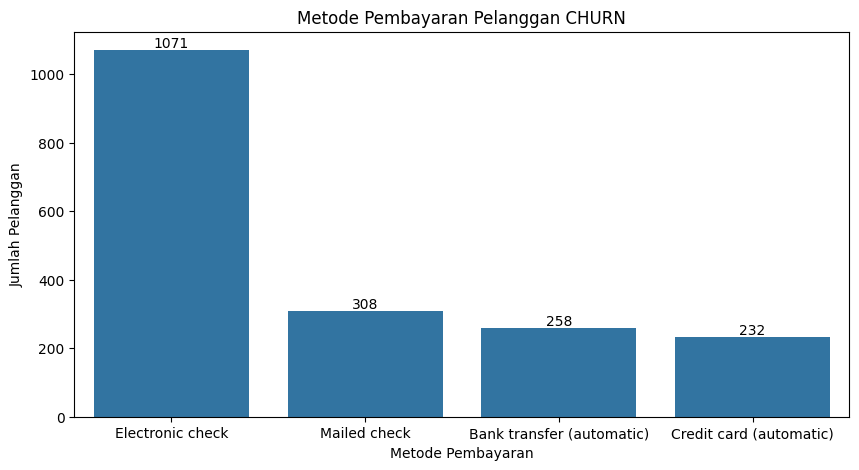

In [ ]:
# Visualisasi PaymentMethod pelanggan yang CHURN

plt.figure(figsize=(10,5))
ax = sns.barplot(x=payment_cust['PaymentMethod'], y=payment_cust['Total_Pelanggan'])
ax.bar_label(ax.containers[0], fontsize=10)
plt.title("Metode Pembayaran Pelanggan CHURN")
plt.ylabel("Jumlah Pelanggan")
plt.xlabel("Metode Pembayaran")
plt.show()

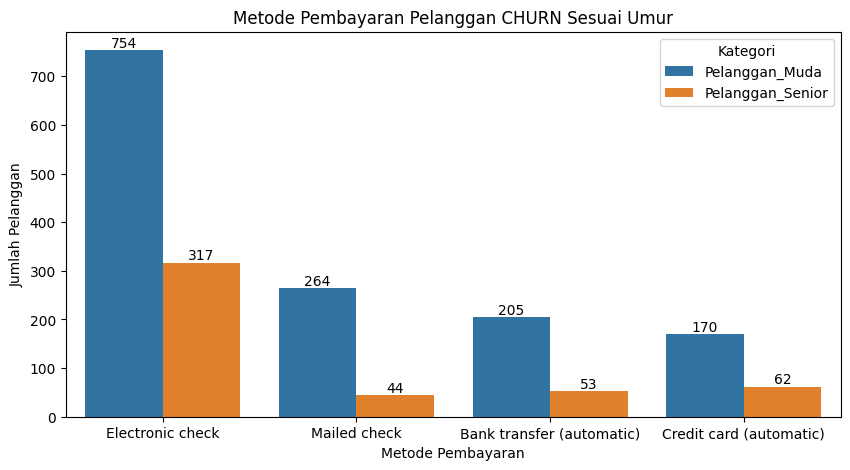

In [ ]:
# Visualisasi PaymentMethod pelanggan yang CHURN berdasarkan umur

visual_umur = payment_cust.melt(id_vars="PaymentMethod", value_vars=["Pelanggan_Muda", "Pelanggan_Senior"], var_name="Kategori", value_name="Jumlah Pelanggan")
plt.figure(figsize=(10,5))
ax = sns.barplot(data = visual_umur, x="PaymentMethod", y="Jumlah Pelanggan", hue="Kategori")
ax.bar_label(ax.containers[0], fontsize=10)
ax.bar_label(ax.containers[1], fontsize=10)
plt.title("Metode Pembayaran Pelanggan CHURN Sesuai Umur")
plt.ylabel("Jumlah Pelanggan")
plt.xlabel("Metode Pembayaran")
plt.show()

In [ ]:
# Chi Square Test -> Melihat Apakah Terdapat Pengaruh/Hubungan dari PaymentMethod dengan Churn
# H0 : Tidak Terdapat hubungan antara PaymentMethod dan Metode Churn
# H1 : Terdapat hubungan antara PaymentMethod dan Metode Churn

comp = pd.crosstab(data['PaymentMethod'], data['Churn'])

stat_chi, pval_chi, dof, exp_freq = chi2_contingency(comp)

display(comp)

if pval_chi < 0.05 :
  print('Tolak H0, Artinya, Terdapat Hubungan Antara PaymentMethod dengan Churn')
else :
  print('Terima H0, Artinya, Tidak Terdapat Hubungan Antara PaymentMethod dengan Churn')

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),1286,258
Credit card (automatic),1290,232
Electronic check,1294,1071
Mailed check,1304,308


Tolak H0, Artinya, Terdapat Hubungan Antara PaymentMethod dengan Churn


**Hasil Yang Ditemukan**

- **Total** pelanggan CHURN pada data adalah **1869 orang**
- **Produk Telco** perusahaan yang **banyak digunakan** pelanggan CHURN adalah **PhoneService** dan **InternetService berupa Fiber Optic**
- **Mayoritas** pelanggan CHURN adalah **orang muda** (No pada `SeniorCitizen`)
- **Mayoritas** pelanggan CHURN **belum memiliki pasangan**. (No pada `Partner`)
- **Mayoritas** pelanggan CHURN **tidak memiliki tanggungan** (No pada `Dependents)`
- **Kontrak** yang paling banyak dipilih pelanggan CHURN adalah **Month-to-month**.
- **Metode pembayaran** yang paling banyak digunakan pelanggan CHURN adalah **electronic check**

### Data Analysis : Tenure

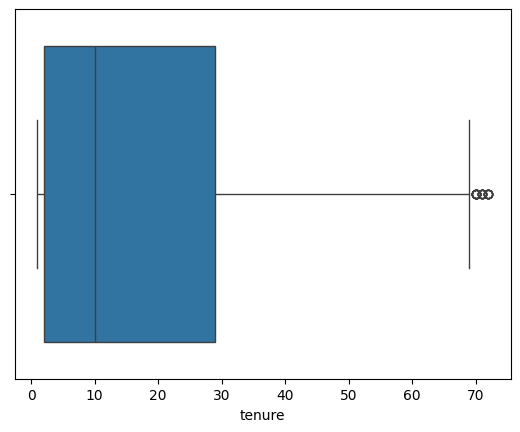

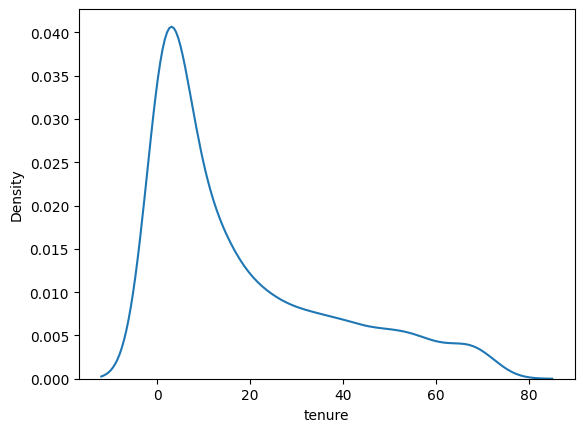

In [ ]:
# Melihat outliers dari data tenure pelanggan CHURN

sns.boxplot(x = demochurn['tenure'])
plt.show()

sns.kdeplot(demochurn['tenure'])
plt.show()

In [ ]:
# Melakukan pengecekan tenur diatas 24 bulan pada pelanggan CHURN (karena maksimal kontrak yang ditawarkan per 2 tahun)

demochurn['tenure'][demochurn['tenure'] > 24].value_counts().sort_index()

,count
tenure,
25,23
26,15
27,13
28,12
29,15
30,16
31,16
32,19
33,14


In [ ]:
# Melakukan pengecekan tenure penyumbang CHURN terbanyak

demochurn['tenure'].value_counts(ascending=False).head(10)

,count
tenure,
1,380
2,123
3,94
4,83
5,64
7,51
9,46
10,45
8,42


In [ ]:
# Mengecek apa pelanggan baru mendapatkan MonthlyCharge (Untuk mengantisipasi bulan pertama dianggap trial)

demochurn[['customerID','MonthlyCharges', 'PhoneService', 'InternetService']][demochurn['tenure'] == 1].sort_values('MonthlyCharges', ascending=True)

,customerID,MonthlyCharges,PhoneService,InternetService
6489,9318-NKNFC,18.85,Yes,No
4348,6121-VZNQB,19.10,Yes,No
5646,5510-BOIUJ,19.25,Yes,No
2096,0761-AETCS,19.30,Yes,No
5585,4667-OHGKG,19.30,Yes,No
...,...,...,...,...
1704,0107-YHINA,99.75,Yes,Fiber optic
4459,3178-FESZO,100.25,Yes,Fiber optic
2208,7216-EWTRS,100.80,Yes,Fiber optic
6482,5419-JPRRN,101.45,Yes,Fiber optic


In [ ]:
# Menghitung jumlah pelanggan berdasarkan tenure pada data

label_tahun = ["Tenure 0-12", "Tenure 13-24", "Tenure 25-36", "Tenure 37-48", "Tenure 49-60", "Tenure >60"]
total_tahun = [data['customerID'][data['tenure'] <= 12].count(),
               data['customerID'][(data['tenure'] > 12) & (data['tenure'] <= 24)].count(),
               data['customerID'][(data['tenure'] > 24) & (data['tenure'] <= 36)].count(),
               data['customerID'][(data['tenure'] > 36) & (data['tenure'] <= 48)].count(),
               data['customerID'][(data['tenure'] > 48) & (data['tenure'] <= 60)].count(),
               data['customerID'][data['tenure'] > 60].count()
               ]
total_loyal = [data['customerID'][(data['tenure'] <= 12) & (data['Churn'] == "No")].count(),
               data['customerID'][(data['tenure'] > 12) & (data['tenure'] <= 24) & (data['Churn'] == "No")].count(),
               data['customerID'][(data['tenure'] > 24) & (data['tenure'] <= 36) & (data['Churn'] == "No")].count(),
               data['customerID'][(data['tenure'] > 36) & (data['tenure'] <= 48) & (data['Churn'] == "No")].count(),
               data['customerID'][(data['tenure'] > 48) & (data['tenure'] <= 60) & (data['Churn'] == "No")].count(),
               data['customerID'][(data['tenure'] > 60) & (data['Churn'] == "No")].count()
               ]
total_churn = [demochurn['customerID'][demochurn['tenure'] <= 12].count(),
               demochurn['customerID'][(demochurn['tenure'] > 12) & (demochurn['tenure'] <= 24)].count(),
               demochurn['customerID'][(demochurn['tenure'] > 24) & (demochurn['tenure'] <= 36)].count(),
               demochurn['customerID'][(demochurn['tenure'] > 36) & (demochurn['tenure'] <= 48)].count(),
               demochurn['customerID'][(demochurn['tenure'] > 48) & (demochurn['tenure'] <= 60)].count(),
               demochurn['customerID'][demochurn['tenure'] > 60].count()
]

persentase = []
i = 0
while i < len(label_tahun):
    persentase.append(total_churn[i]/total_tahun[i]*100)
    i+=1


In [ ]:
# Membuat tabel total persentase churn dari tiap periode churn

cek_tenure = {
    "Tenure" : label_tahun,
    "Total Pelanggan" : total_tahun,
    "Pelanggan Loyal" : total_loyal,
    "Pelanggan CHURN" : total_churn,
    "Persentase CHURN" : persentase
}

df_tenure = pd.DataFrame(cek_tenure)
print("Total Pelanggan Berdasarkan Tenure")
display(df_tenure)

Total Pelanggan Berdasarkan Tenure


,Tenure,Total Pelanggan,Pelanggan Loyal,Pelanggan CHURN,Persentase CHURN
0,Tenure 0-12,2186,1149,1037,47.438243
1,Tenure 13-24,1024,730,294,28.710938
2,Tenure 25-36,832,652,180,21.634615
3,Tenure 37-48,762,617,145,19.028871
4,Tenure 49-60,832,712,120,14.423077
5,Tenure >60,1407,1314,93,6.609808


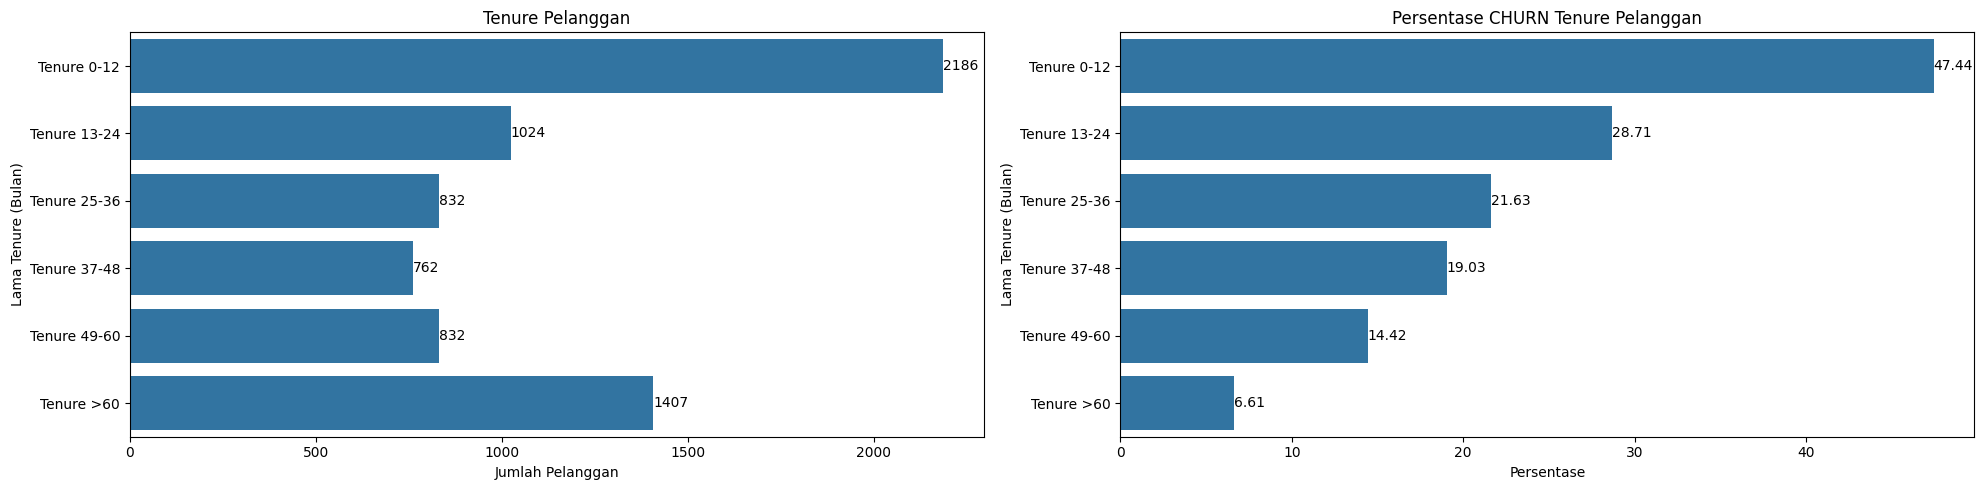

In [ ]:
# Visualisasi Churn Pelanggan
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(20,5))

sns.barplot(y=df_tenure["Tenure"], x=df_tenure['Total Pelanggan'], ax=axes[0])
axes[0].bar_label(axes[0].containers[0], fontsize=10)
axes[0].set_title("Tenure Pelanggan")
axes[0].set_ylabel("Lama Tenure (Bulan)")
axes[0].set_xlabel("Jumlah Pelanggan")

sns.barplot(y=df_tenure['Tenure'], x=df_tenure["Persentase CHURN"].round(2), ax=axes[1])
axes[1].bar_label(axes[1].containers[0], fontsize=10)
axes[1].set_title("Persentase CHURN Tenure Pelanggan")
axes[1].set_ylabel("Lama Tenure (Bulan)")
axes[1].set_xlabel("Persentase")

plt.tight_layout()
plt.show()

**Hasil Yang Ditemukan**

* CHURN **paling banyak** terjadi pada **pelanggan baru** (tenure 1 bulan) sebesar **380 orang**
* Jika dikategorikan per 12 bulan, CHURN **paling besar** terjadi pada **kategori tenure 0-12 bulan** (1 tahun) yaitu **47.44%**
* Semakin lama/besar tenure pelanggan, semakin sedikit jumlah CHURN terjadi.

### Data Analysis: Pelanggan

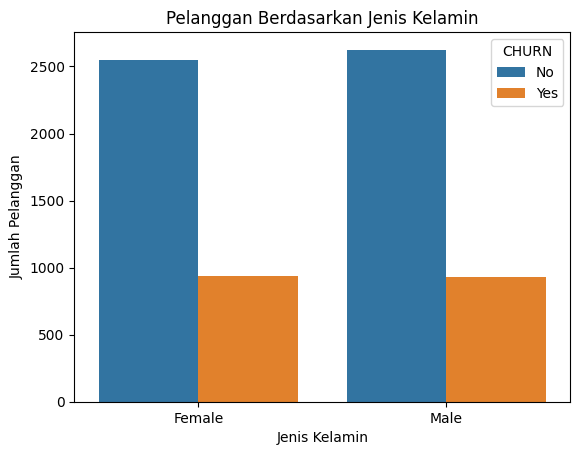

In [ ]:
# Jumlah pelanggan berdasarkan jenis kelamin

sns.countplot(data, x='gender', hue='Churn')
plt.title("Pelanggan Berdasarkan Jenis Kelamin")
plt.xlabel("Jenis Kelamin")
plt.ylabel("Jumlah Pelanggan")
plt.legend(title="CHURN")
plt.show()

In [ ]:
# Chi Square Test -> Melihat Apakah Terdapat Pengaruh/Hubungan dari Gender dengan Churn
# H0 : Tidak Terdapat hubungan antara Gender dan Churn
# H1 : Terdapat hubungan antara Gender dan Churn

comp = pd.crosstab(data['gender'], data['Churn'])

stat_chi, pval_chi, dof, exp_freq = chi2_contingency(comp)

display(comp)

if pval_chi < 0.05 :
  print('Tolak H0, Artinya, Terdapat Hubungan Antara Gender dengan Churn')
else :
  print('Terima H0, Artinya, Tidak Terdapat Hubungan Antara Gender dengan Churn')

Churn,No,Yes
gender,,
Female,2549,939
Male,2625,930


Terima H0, Artinya, Tidak Terdapat Hubungan Antara Gender dengan Churn


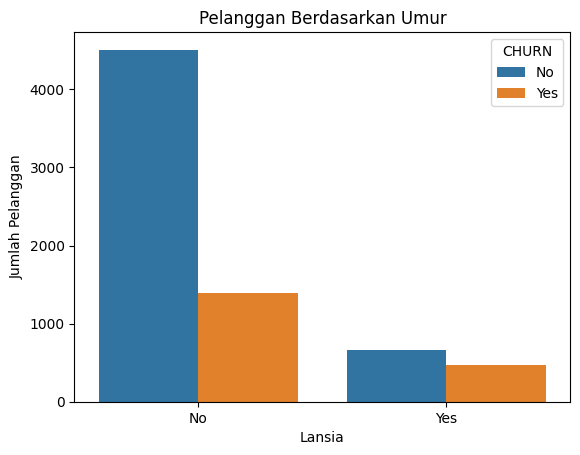

In [ ]:
# Jumlah pelanggan berdasarkan umur

sns.countplot(data, x='SeniorCitizen', hue='Churn')
plt.title("Pelanggan Berdasarkan Umur")
plt.xlabel("Lansia")
plt.ylabel("Jumlah Pelanggan")
plt.legend(title="CHURN")
plt.show()

In [ ]:
# Chi Square Test -> Melihat Apakah Terdapat Pengaruh/Hubungan dari SeniorCitizen dengan Churn
# H0 : Tidak Terdapat hubungan antara SeniorCitizen dan Churn
# H1 : Terdapat hubungan antara SeniorCitizen dan Churn

comp = pd.crosstab(data['SeniorCitizen'], data['Churn'])

stat_chi, pval_chi, dof, exp_freq = chi2_contingency(comp)

display(comp)

if pval_chi < 0.05 :
  print('Tolak H0, Artinya, Terdapat Hubungan Antara SeniorCitizen dengan Churn')
else :
  print('Terima H0, Artinya, Tidak Terdapat Hubungan Antara SeniorCitizen dengan Churn')

Churn,No,Yes
SeniorCitizen,,
No,4508,1393
Yes,666,476


Tolak H0, Artinya, Terdapat Hubungan Antara SeniorCitizen dengan Churn


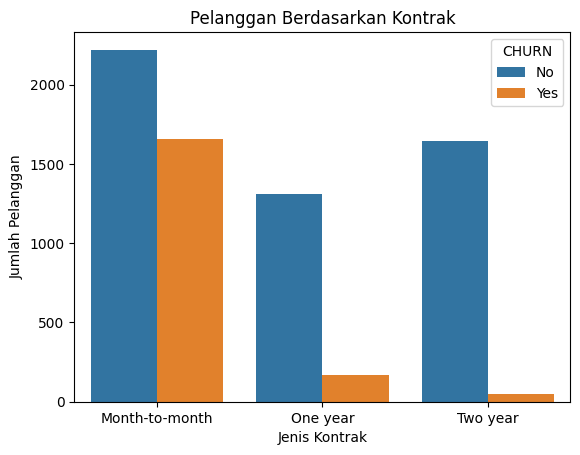

In [ ]:
# Jumlah pelanggan berdasarkan jenis kontrak

sns.countplot(data, x='Contract', hue='Churn')
plt.title("Pelanggan Berdasarkan Kontrak")
plt.xlabel("Jenis Kontrak")
plt.ylabel("Jumlah Pelanggan")
plt.legend(title="CHURN")
plt.show()

In [ ]:
# Chi Square Test -> Melihat Apakah Terdapat Pengaruh/Hubungan dari Contract dengan Churn
# H0 : Tidak Terdapat hubungan antara Contract dan Churn
# H1 : Terdapat hubungan antara Contract dan Churn

comp = pd.crosstab(data['Contract'], data['Churn'])

stat_chi, pval_chi, dof, exp_freq = chi2_contingency(comp)

display(comp)

if pval_chi < 0.05 :
  print('Tolak H0, Artinya, Terdapat Hubungan Antara Contract dengan Churn')
else :
  print('Terima H0, Artinya, Tidak Terdapat Hubungan Antara Contract dengan Churn')

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


Tolak H0, Artinya, Terdapat Hubungan Antara Contract dengan Churn


**CATATAN**

**Produk utama** pada data perusahaan Telco yang digunakan adalah **Phone Service** dan **Internet Service**.

Oleh karena itu, akan dilihat jumlah pelanggan dari kedua produk ini.

In [ ]:
# Total pelanggan berdasarkan penggunaan Phone Service dan Internet Service

data[['customerID', "PhoneService" ,"InternetService"]].groupby(["PhoneService", "InternetService"]).count().sort_values(['PhoneService', 'customerID'], ascending=False)

customerID
PhoneService InternetService            
Yes          Fiber optic            3096
             DSL                    1739
             No                     1526
No           DSL                     682

In [ ]:
# Total pelanggan CHURN berdasarkan penggunaan Phone Service dan Internet Service

demochurn[['customerID', "PhoneService" ,"InternetService"]].groupby(["PhoneService", "InternetService"]).count().sort_values(['PhoneService', 'customerID'], ascending=False)

customerID
PhoneService InternetService            
Yes          Fiber optic            1297
             DSL                     289
             No                      113
No           DSL                     170

In [ ]:
# Menghitung jumlah pengguna dari setiap Tambahan Layanan Internet

# Jenis-jenis Tambahan Layanan Internet yang ada
produk_int = ["OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"]

# Menghitung total pengguna setiap Tambahan Layanan Internet
freq_total = [data['OnlineSecurity'][data['OnlineSecurity'] == 'Yes'].count(),
            data['OnlineBackup'][data['OnlineBackup'] == 'Yes'].count(),
            data['DeviceProtection'][data['DeviceProtection'] == 'Yes'].count(),
            data['TechSupport'][data['TechSupport'] == 'Yes'].count(),
            data['StreamingTV'][data['StreamingTV'] == 'Yes'].count(),
            data['StreamingMovies'][data['StreamingMovies'] == 'Yes'].count()]

# Menghitung total pengguna setiap Tambahan Layanan Internet YANG LOYAL
freq_loyal = [data['OnlineSecurity'][(data['OnlineSecurity'] == 'Yes') & (data['Churn'] == 'No')].count(),
            data['OnlineBackup'][(data['OnlineBackup'] == 'Yes') & (data['Churn'] == 'No')].count(),
            data['DeviceProtection'][(data['DeviceProtection'] == 'Yes') & (data['Churn'] == 'No')].count(),
            data['TechSupport'][(data['TechSupport'] == 'Yes') & (data['Churn'] == 'No')].count(),
            data['StreamingTV'][(data['StreamingTV'] == 'Yes') & (data['Churn'] == 'No')].count(),
            data['StreamingMovies'][(data['StreamingMovies'] == 'Yes') & (data['Churn'] == 'No')].count()]

# Menghitung total pengguna setiap Tambahan Layanan Internet YANG CHURN
freq_churn = [demochurn['OnlineSecurity'][demochurn['OnlineSecurity'] == 'Yes'].count(),
            demochurn['OnlineBackup'][demochurn['OnlineBackup'] == 'Yes'].count(),
            demochurn['DeviceProtection'][demochurn['DeviceProtection'] == 'Yes'].count(),
            demochurn['TechSupport'][demochurn['TechSupport'] == 'Yes'].count(),
            demochurn['StreamingTV'][demochurn['StreamingTV'] == 'Yes'].count(),
            demochurn['StreamingMovies'][demochurn['StreamingMovies'] == 'Yes'].count()]

# Membuat dataframe yang akan digunakan
servis_cust = {
    "Tambahan Layanan Internet": produk_int,
    "Total Pengguna": freq_total,
    "Pengguna Loyal": freq_loyal,
    "Pengguna CHURN": freq_churn,
    }
df_servis = pd.DataFrame(servis_cust)

# Membuat kolom persentase CHURN
df_servis["Persentase CHURN"] = (df_servis["Pengguna CHURN"] / df_servis["Total Pengguna"] * 100).round(2)

print("Tabel Total Pengguna Tambahan Layanan Internet")
display(df_servis)

Tabel Total Pengguna Tambahan Layanan Internet


,Tambahan Layanan Internet,Total Pengguna,Pengguna Loyal,Pengguna CHURN,Persentase CHURN
0,OnlineSecurity,2019,1724,295,14.61
1,OnlineBackup,2429,1906,523,21.53
2,DeviceProtection,2422,1877,545,22.50
3,TechSupport,2044,1734,310,15.17
4,StreamingTV,2707,1893,814,30.07
5,StreamingMovies,2732,1914,818,29.94


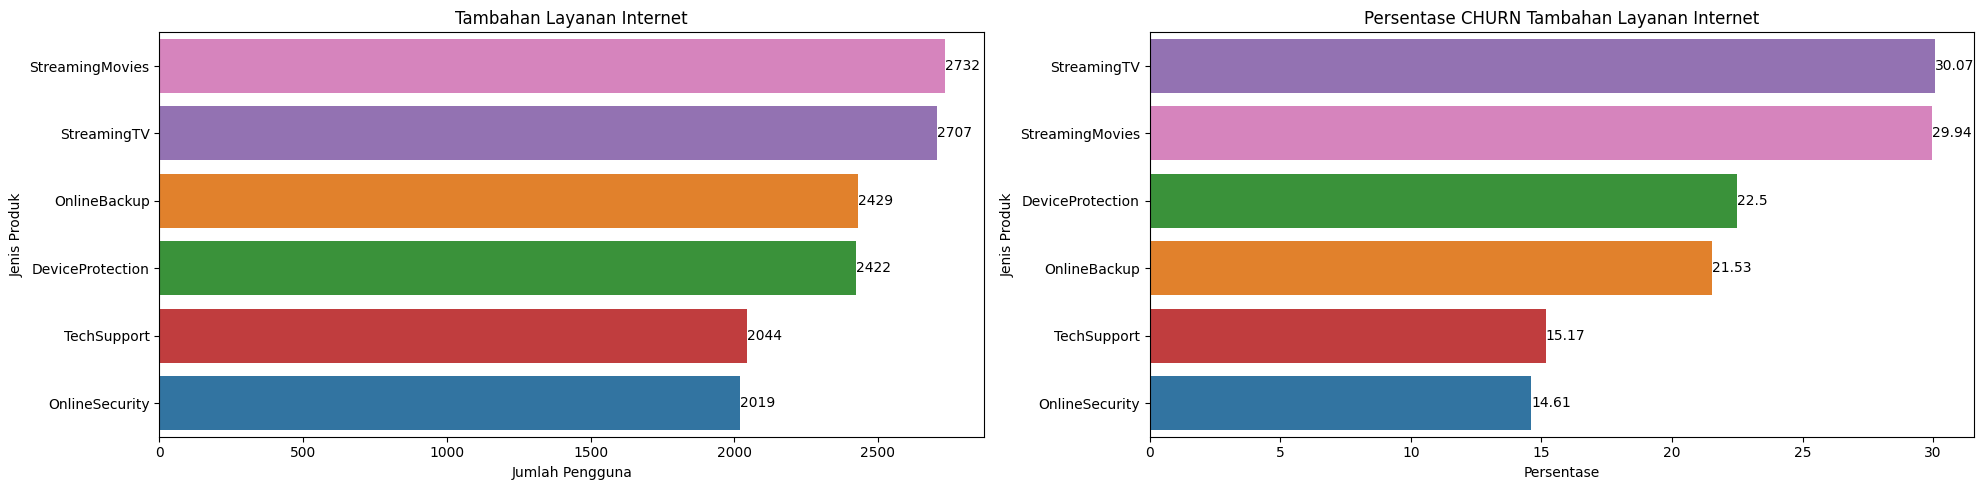

In [ ]:
# Visualisasi Jumlah Pengguna Setiap Produk Layanan Internet
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(20,5))

color_servis = {
    "OnlineSecurity" : "tab:blue",
    "OnlineBackup" : "tab:orange",
    "DeviceProtection" : "tab:green",
    "TechSupport" : "tab:red",
    "StreamingTV" : "tab:purple",
    "StreamingMovies" : "tab:pink",
}

sns.barplot(data=df_servis.sort_values(by="Total Pengguna", ascending=False), y="Tambahan Layanan Internet", x='Total Pengguna', palette=color_servis, ax=axes[0])
for i in range(len(df_servis['Tambahan Layanan Internet'])):
  axes[0].bar_label(axes[0].containers[i], fontsize=10)
axes[0].set_title("Tambahan Layanan Internet")
axes[0].set_ylabel("Jenis Produk")
axes[0].set_xlabel("Jumlah Pengguna")

sns.barplot(data=df_servis.sort_values(by="Persentase CHURN", ascending=False), y="Tambahan Layanan Internet", x="Persentase CHURN", palette=color_servis, ax=axes[1])
for i in range(len(df_servis['Tambahan Layanan Internet'])):
  axes[1].bar_label(axes[1].containers[i], fontsize=10)
axes[1].set_title("Persentase CHURN Tambahan Layanan Internet")
axes[1].set_ylabel("Jenis Produk")
axes[1].set_xlabel("Persentase")

plt.tight_layout()
plt.show()

In [ ]:
# Melihat jumlah pengguna setiap Tambahan Layanan Internet berdasarkan tenure
# Digunakan untuk melihat Tambahan Layanan Internet yang digunakan setiap pelanggan berdasarkan tenure

cek_movies = data[data["StreamingMovies"] == "Yes"].agg(
    Satu_Tahun = ("tenure", lambda x: (x<=12).sum()),
    Dua_Tahun = ("tenure", lambda x: ((x>12) & (x<=24)).sum()),
    Tiga_Tahun = ("tenure", lambda x: ((x>24) & (x<=36)).sum()),
    Empat_Tahun = ("tenure", lambda x: ((x>36) & (x<=48)).sum()),
    Lima_Tahun = ("tenure", lambda x: ((x>48) & (x<=60)).sum()),
    Di_Atas_Lima_Tahun = ("tenure", lambda x: (x>60).sum())
    ).reset_index()
cek_movies.rename(columns={"index":"Lama Tenure", "tenure":"Pengguna Movies"}, inplace=True)

cek_tv = data[data["StreamingTV"] == "Yes"].agg(
    Satu_Tahun = ("tenure", lambda x: (x<=12).sum()),
    Dua_Tahun = ("tenure", lambda x: ((x>12) & (x<=24)).sum()),
    Tiga_Tahun = ("tenure", lambda x: ((x>24) & (x<=36)).sum()),
    Empat_Tahun = ("tenure", lambda x: ((x>36) & (x<=48)).sum()),
    Lima_Tahun = ("tenure", lambda x: ((x>48) & (x<=60)).sum()),
    Di_Atas_Lima_Tahun = ("tenure", lambda x: (x>60).sum())
    ).reset_index()
cek_tv.rename(columns={"index":"Lama Tenure", "tenure":"Pengguna TV"}, inplace=True)

cek_backup = data[data["OnlineBackup"] == "Yes"].agg(
    Satu_Tahun = ("tenure", lambda x: (x<=12).sum()),
    Dua_Tahun = ("tenure", lambda x: ((x>12) & (x<=24)).sum()),
    Tiga_Tahun = ("tenure", lambda x: ((x>24) & (x<=36)).sum()),
    Empat_Tahun = ("tenure", lambda x: ((x>36) & (x<=48)).sum()),
    Lima_Tahun = ("tenure", lambda x: ((x>48) & (x<=60)).sum()),
    Di_Atas_Lima_Tahun = ("tenure", lambda x: (x>60).sum())
    ).reset_index()
cek_backup.rename(columns={"index":"Lama Tenure", "tenure":"Pengguna OnlineBackup"}, inplace=True)

cek_device = data[data["DeviceProtection"] == "Yes"].agg(
    Satu_Tahun = ("tenure", lambda x: (x<=12).sum()),
    Dua_Tahun = ("tenure", lambda x: ((x>12) & (x<=24)).sum()),
    Tiga_Tahun = ("tenure", lambda x: ((x>24) & (x<=36)).sum()),
    Empat_Tahun = ("tenure", lambda x: ((x>36) & (x<=48)).sum()),
    Lima_Tahun = ("tenure", lambda x: ((x>48) & (x<=60)).sum()),
    Di_Atas_Lima_Tahun = ("tenure", lambda x: (x>60).sum())
    ).reset_index()
cek_device.rename(columns={"index":"Lama Tenure", "tenure":"Pengguna DeviceProtection"}, inplace=True)

cek_tech = data[data["TechSupport"] == "Yes"].agg(
    Satu_Tahun = ("tenure", lambda x: (x<=12).sum()),
    Dua_Tahun = ("tenure", lambda x: ((x>12) & (x<=24)).sum()),
    Tiga_Tahun = ("tenure", lambda x: ((x>24) & (x<=36)).sum()),
    Empat_Tahun = ("tenure", lambda x: ((x>36) & (x<=48)).sum()),
    Lima_Tahun = ("tenure", lambda x: ((x>48) & (x<=60)).sum()),
    Di_Atas_Lima_Tahun = ("tenure", lambda x: (x>60).sum())
    ).reset_index()
cek_tech.rename(columns={"index":"Lama Tenure", "tenure":"Pengguna TechSupport"}, inplace=True)

cek_security = data[data["OnlineSecurity"] == "Yes"].agg(
    Satu_Tahun = ("tenure", lambda x: (x<=12).sum()),
    Dua_Tahun = ("tenure", lambda x: ((x>12) & (x<=24)).sum()),
    Tiga_Tahun = ("tenure", lambda x: ((x>24) & (x<=36)).sum()),
    Empat_Tahun = ("tenure", lambda x: ((x>36) & (x<=48)).sum()),
    Lima_Tahun = ("tenure", lambda x: ((x>48) & (x<=60)).sum()),
    Di_Atas_Lima_Tahun = ("tenure", lambda x: (x>60).sum())
    ).reset_index()
cek_security.rename(columns={"index":"Lama Tenure", "tenure":"Pengguna OnlineSecurity"}, inplace=True)

merge_int = pd.merge(cek_movies, cek_tv, on="Lama Tenure", how="left")
merge_int = pd.merge(merge_int, cek_backup, on="Lama Tenure", how="left")
merge_int = pd.merge(merge_int, cek_device, on="Lama Tenure", how="left")
merge_int = pd.merge(merge_int, cek_tech, on="Lama Tenure", how="left")
merge_int = pd.merge(merge_int, cek_security, on="Lama Tenure", how="left")
merge_int

,Lama Tenure,Pengguna Movies,Pengguna TV,Pengguna OnlineBackup,Pengguna DeviceProtection,Pengguna TechSupport,Pengguna OnlineSecurity
0,Satu_Tahun,495,491,341,329,283,271
1,Dua_Tahun,332,333,254,261,216,231
2,Tiga_Tahun,330,322,279,285,248,221
3,Empat_Tahun,325,332,303,326,244,246
4,Lima_Tahun,419,417,394,369,306,312
5,Di_Atas_Lima_Tahun,831,812,858,852,747,738


In [ ]:
# Membuat fungsi tambahan dari uji tes Chi Square menggunakan Cramer's V untuk menentukan korelasi yang lebih kuat

# Fungsi Cramer's V
def cramers_v(confusion_matrix):
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape

    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

# Buat kolom kategori
categorical_cols = [
    'gender',
    'SeniorCitizen',
    'Partner',
    'Dependents',
    'PhoneService',
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'Contract',
    'PaperlessBilling',
    'PaymentMethod'
]

results = []

for col in categorical_cols:
    table = pd.crosstab(data[col], data['Churn'])

    chi2, p, dof, expected = chi2_contingency(table)
    cv = cramers_v(table)

    results.append({
        'Variable': col,
        'P_Value': round(p,5),
        'Cramers_V': cv,
    })

# Buat DataFrame
cramer_data = pd.DataFrame(results)

# Urutkan berdasarkan Cramer's V
cramer_data = cramer_data.sort_values(
    by='Cramers_V',
    ascending=False
).reset_index(drop=True)

# Tambahkan ranking
cramer_data['Rank'] = cramer_data.index + 1

# Rapikan tampilan
cramer_data['P_Value'] = cramer_data['P_Value'].round(5)
cramer_data['Cramers_V'] = cramer_data['Cramers_V'].round(3)

print(cramer_data)

            Variable  P_Value  Cramers_V  Rank
0           Contract  0.00000      0.410     1
1     OnlineSecurity  0.00000      0.347     2
2        TechSupport  0.00000      0.343     3
3    InternetService  0.00000      0.322     4
4      PaymentMethod  0.00000      0.303     5
5       OnlineBackup  0.00000      0.292     6
6   DeviceProtection  0.00000      0.282     7
7    StreamingMovies  0.00000      0.231     8
8        StreamingTV  0.00000      0.231     9
9   PaperlessBilling  0.00000      0.191    10
10        Dependents  0.00000      0.164    11
11     SeniorCitizen  0.00000      0.150    12
12           Partner  0.00000      0.150    13
13     MultipleLines  0.00346      0.040    14
14      PhoneService  0.33878      0.011    15
15            gender  0.48658      0.008    16


**Hasil Yang Ditemukan**

- Jenis kelamin pelanggan **tidak mempengaruhi** CHURN

- Umur pelanggan **mempengaruhi** CHURN, di mana **pelanggan lansia kurang tertarik** kepada produk perusahaan dan **cenderung untuk CHURN**

- Kontrak produk  **mempengaruhi** CHURN, di mana kontrak **Month-to-month** adalah kontrak dengan **jumlah pelanggan terbesar** tetapi memiliki **CHURN terbesar** juga.

- Pada produk utama, pelanggan **paling banyak** menggunakan **Layanan Telepon dengan Layanan Internet berupa fiber optic**

- Berdasarkan **tambahan layanan internet**, yang **paling banyak digunakan** pelanggan adalah **StreamingMovies dan StreamingTV**

- **StreamingMovies dan StreamingTV** memiliki **CHURN terbesar**, hal ini bisa **disebabkan** CHURN umumnya terjadi pada pelanggan baru dan pelanggan baru lebih sering hanya mencoba kedua produk ini.

### Data Analysis: Revenue

#### Revenue dari TotalCharge

In [ ]:
# Total Revenue semua pelanggan dari pengguna Phone Service dan Internet Service # Kategorikan lagi tenure nya

data[['TotalCharges', "PhoneService" ,"InternetService"]].groupby(["PhoneService", "InternetService"]).sum().sort_values(['PhoneService', 'TotalCharges'], ascending=False)

TotalCharges
PhoneService InternetService              
Yes          Fiber optic        9923622.95
             DSL                4101115.90
             No                 1011134.90
No           DSL                1020294.95

In [ ]:
# Total Revenue pelanggan yang CHURN saja dari pengguna Phone Service dan Internet Service

demochurn[['TotalCharges', "PhoneService" ,"InternetService"]].groupby(["PhoneService", "InternetService"]).sum().sort_values(['PhoneService', 'TotalCharges'], ascending=False)

TotalCharges
PhoneService InternetService              
Yes          Fiber optic        2483257.45
             DSL                 243211.55
             No                   19652.95
No           DSL                 116804.95

#### Revenue dari MonthlyCharges

In [ ]:
# Total Revenue semua pelanggan dari pengguna Phone Service dan Internet Service #Tambah kolom baru jumlah servis yang dipakai

data[['MonthlyCharges', "PhoneService" ,"InternetService"]].groupby(["PhoneService", "InternetService"]).sum().sort_values(['PhoneService', 'MonthlyCharges'], ascending=False)

MonthlyCharges
PhoneService InternetService                
Yes          Fiber optic           283284.40
             DSL                   112001.85
             No                     32166.85
No           DSL                    28663.50

In [ ]:
# Total Revenue pelanggan yang CHURN saja dari pengguna Phone Service dan Internet Service

demochurn[['MonthlyCharges', "PhoneService" ,"InternetService"]].groupby(["PhoneService", "InternetService"]).sum().sort_values(['PhoneService', 'MonthlyCharges'], ascending=False)

MonthlyCharges
PhoneService InternetService                
Yes          Fiber optic           114300.05
             DSL                    16148.45
             No                      2301.60
No           DSL                     6380.75

In [ ]:
# Total Revenue pelanggan pengguna Phone Service baik pengguna maupun tidak Multiplelines

data[['MonthlyCharges', "MultipleLines"]][data['PhoneService'] == "Yes"].groupby("MultipleLines").sum().sort_values("MonthlyCharges", ascending=False)

,MonthlyCharges
MultipleLines,
Yes,243731.85
No,183721.25


In [ ]:
# Total Revenue pelanggan pengguna Phone Service baik pengguna maupun tidak Multiplelines yang Churn

data[['MonthlyCharges', "MultipleLines", "Churn"]][data['PhoneService'] == "Yes"]\
    .groupby(["MultipleLines", "Churn"]).sum().sort_values(["MultipleLines", "MonthlyCharges"], ascending=[False, False])

MonthlyCharges
MultipleLines Churn                
Yes           No          168021.35
              Yes          75710.50
No            No          126681.65
              Yes          57039.60

In [ ]:
# Total Revenue pelanggan pengguna Internet Service

data[['MonthlyCharges', "InternetService"]][data['InternetService'] != "No"].groupby("InternetService").sum().sort_values("MonthlyCharges", ascending=False)

,MonthlyCharges
InternetService,
Fiber optic,283284.40
DSL,140665.35


In [ ]:
# Total Revenue pelanggan pengguna Internet Service berdasarkan Churn

data[['MonthlyCharges', "InternetService", "Churn"]][data['InternetService'] != "No"].groupby(["InternetService", "Churn"]).sum().sort_values(["InternetService", "MonthlyCharges"], ascending=[True, False])

MonthlyCharges
InternetService Churn                
DSL             No          118136.15
                Yes          22529.20
Fiber optic     No          168984.35
                Yes         114300.05

In [ ]:
# Menghitung jumlah pelanggan berdasarkan tenure pada data

revmonth_int = ["OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"]
revmonth_all = [data['MonthlyCharges'][data['OnlineSecurity'] == 'Yes'].sum(),
            data['MonthlyCharges'][data['OnlineBackup'] == 'Yes'].sum(),
            data['MonthlyCharges'][data['DeviceProtection'] == 'Yes'].sum(),
            data['MonthlyCharges'][data['TechSupport'] == 'Yes'].sum(),
            data['MonthlyCharges'][data['StreamingTV'] == 'Yes'].sum(),
            data['MonthlyCharges'][data['StreamingMovies'] == 'Yes'].sum()]

revmonth_loyal = [data['MonthlyCharges'][(data['OnlineSecurity'] == 'Yes')&(data['Churn'] == 'No')].sum(),
            data['MonthlyCharges'][(data['OnlineBackup'] == 'Yes')&(data['Churn'] == 'No')].sum(),
            data['MonthlyCharges'][(data['DeviceProtection'] == 'Yes')&(data['Churn'] == 'No')].sum(),
            data['MonthlyCharges'][(data['TechSupport'] == 'Yes')&(data['Churn'] == 'No')].sum(),
            data['MonthlyCharges'][(data['StreamingTV'] == 'Yes')&(data['Churn'] == 'No')].sum(),
            data['MonthlyCharges'][(data['StreamingMovies'] == 'Yes')&(data['Churn'] == 'No')].sum()]

revmonth_churn = [demochurn['MonthlyCharges'][demochurn['OnlineSecurity'] == 'Yes'].sum(),
            demochurn['MonthlyCharges'][demochurn['OnlineBackup'] == 'Yes'].sum(),
            demochurn['MonthlyCharges'][demochurn['DeviceProtection'] == 'Yes'].sum(),
            demochurn['MonthlyCharges'][demochurn['TechSupport'] == 'Yes'].sum(),
            demochurn['MonthlyCharges'][demochurn['StreamingTV'] == 'Yes'].sum(),
            demochurn['MonthlyCharges'][demochurn['StreamingMovies'] == 'Yes'].sum()]

# Membuat tabel revenue monthly setiap produk layanan internet
cek_revmonth = {
    "Jenis Produk" : revmonth_int,
    "Total Rev_Monthly" : revmonth_all,
    "Rev_Monthly Gain" : revmonth_loyal,
    "Rev_Monthly Loss" : revmonth_churn
}
df_revmonth = pd.DataFrame(cek_revmonth)

# Membuat kolom persentase CHURN
df_revmonth["Persentase Revenue Loss"] = (df_revmonth["Rev_Monthly Loss"] / df_revmonth["Total Rev_Monthly"] * 100).round(2)

print("Revenue Monthly Setiap Produk Layanan Internet")
display(df_revmonth)

Revenue Monthly Setiap Produk Layanan Internet


,Jenis Produk,Total Rev_Monthly,Rev_Monthly Gain,Rev_Monthly Loss,Persentase Revenue Loss
0,OnlineSecurity,159175.40,135108.90,24066.50,15.12
1,OnlineBackup,201805.20,156849.80,44955.40,22.28
2,DeviceProtection,205439.50,157362.50,48077.00,23.40
3,TechSupport,164910.20,138790.75,26119.45,15.84
4,StreamingTV,240210.35,166545.50,73664.85,30.67
5,StreamingMovies,241715.65,168149.95,73565.70,30.43


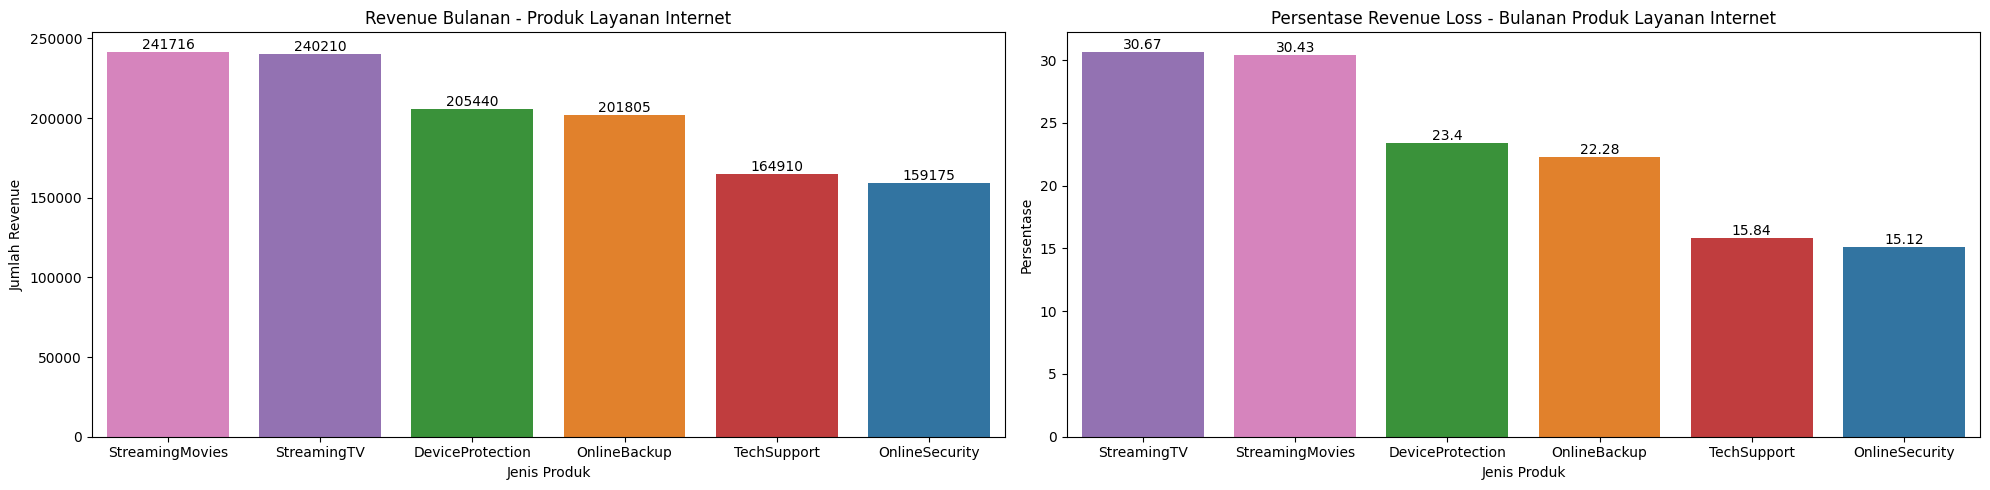

In [ ]:
# Visualisasi Revenue Monthly Setiap Produk Layanan Internet
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(20,5))

color_servis = {
    "OnlineSecurity" : "tab:blue",
    "OnlineBackup" : "tab:orange",
    "DeviceProtection" : "tab:green",
    "TechSupport" : "tab:red",
    "StreamingTV" : "tab:purple",
    "StreamingMovies" : "tab:pink",
}

sns.barplot(data=df_revmonth.sort_values(by="Total Rev_Monthly", ascending=False), x="Jenis Produk", y='Total Rev_Monthly', palette=color_servis, ax=axes[0])
for i in range(len(df_revmonth['Jenis Produk'])):
  axes[0].bar_label(axes[0].containers[i], fontsize=10)
axes[0].set_title("Revenue Bulanan - Produk Layanan Internet")
axes[0].set_xlabel("Jenis Produk")
axes[0].set_ylabel("Jumlah Revenue")

sns.barplot(data=df_revmonth.sort_values(by="Persentase Revenue Loss", ascending=False), x="Jenis Produk", y="Persentase Revenue Loss", palette=color_servis, ax=axes[1])
for i in range(len(df_revmonth['Jenis Produk'])):
  axes[1].bar_label(axes[1].containers[i], fontsize=10)
axes[1].set_title("Persentase Revenue Loss - Bulanan Produk Layanan Internet")
axes[1].set_xlabel("Jenis Produk")
axes[1].set_ylabel("Persentase")

plt.tight_layout()
plt.show()

**CATATAN**

Untuk nilai revenue, pada data ini hanya *mungkin bisa* diperoleh dari kolom `MonthlyCharges` dan `TotalCharges`. Hal ini dikarenakan **data lebih berisi demografi pelanggan**, BUKAN data transaksi pelanggan

**Hasil Yang Ditemukan**

- Pada produk utama, **Layanan Telepon beserta fiber optic** (Layanan Internet) menghasilkan **revenue bulanan terbesar** dan **revenue total terbesar**. Hal ini bisa dikarenakan gabungan produk ini lebih diminati pelanggan.

- Dilihat dari **Layanan Internet** saja, **fiber optic** memberikan **revenue bulanan** terbesar.

- **StreamingMovies dan StreamingTV** menghasilkan **revenue bulanan terbesar** tetapi juga memiliki **revenue loss bulanan terbesar** akibat pelanggan CHURN. Hal ini bisa dikarenakan kedua produk ini memiliki jumlah pengguna terbanyak.

### Data Analysis: Tenure dengan Kategori

In [ ]:
# Membuat dataframe untuk menghitung tambahan layanan internet yang digunakan per pengguna
hitungservis = data[["customerID", "OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"]].copy()
hitungservis.head(5)

,customerID,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
0,7590-VHVEG,No,Yes,No,No,No,No
1,5575-GNVDE,Yes,No,Yes,No,No,No
2,3668-QPYBK,Yes,Yes,No,No,No,No
3,7795-CFOCW,Yes,No,Yes,Yes,No,No
4,9237-HQITU,No,No,No,No,No,No


In [ ]:
# Mengubah isi setiap tambahan layanan internet ke dalam angka untuk memudahkan perhitungan
kolom_cek = ["OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"]

for i in kolom_cek :
    hitungservis[i].replace(["No", "No internet service", "Yes"], ["0", "0", "1"], inplace=True)

for i in kolom_cek :
    hitungservis[i] = pd.to_numeric(hitungservis[i])

# Melihat apakah sudah berhasil berubah
hitungservis.info()
hitungservis.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   customerID        7043 non-null   object
 1   OnlineSecurity    7043 non-null   int64 
 2   OnlineBackup      7043 non-null   int64 
 3   DeviceProtection  7043 non-null   int64 
 4   TechSupport       7043 non-null   int64 
 5   StreamingTV       7043 non-null   int64 
 6   StreamingMovies   7043 non-null   int64 
dtypes: int64(6), object(1)
memory usage: 385.3+ KB


,customerID,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
0,7590-VHVEG,0,1,0,0,0,0
1,5575-GNVDE,1,0,1,0,0,0
2,3668-QPYBK,1,1,0,0,0,0
3,7795-CFOCW,1,0,1,1,0,0
4,9237-HQITU,0,0,0,0,0,0


In [ ]:
# Menjumlahkan tambahan layanan internet yang digunakan per pelanggan
hitungservis["Penggunaan Layanan Internet"] = hitungservis[["OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"]].sum(axis=1)
hitungservis.head()

,customerID,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Penggunaan Layanan Internet
0,7590-VHVEG,0,1,0,0,0,0,1
1,5575-GNVDE,1,0,1,0,0,0,2
2,3668-QPYBK,1,1,0,0,0,0,2
3,7795-CFOCW,1,0,1,1,0,0,3
4,9237-HQITU,0,0,0,0,0,0,0


In [ ]:
# Memasukkan ke dalam data asli untuk dipakai
data["Tambahan Layanan Internet"] = hitungservis["Penggunaan Layanan Internet"]
data['Tambahan Layanan Internet'] = data['Tambahan Layanan Internet'].astype(str)

print(data['Tambahan Layanan Internet'].dtypes)
data.head()

object


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Tambahan Layanan Internet
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,1
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,2
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,2
3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,3
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,0


In [ ]:
# Membuat kolom kategori tenure

# Syarat kolom kategori tenure
syarat = [
    (data['tenure'] <= 12),
    (data['tenure'] > 12) & (data['tenure'] <= 24),
    (data['tenure'] > 24) & (data['tenure'] <= 36),
    (data['tenure'] > 36) & (data['tenure'] <= 48),
    (data['tenure'] > 48) & (data['tenure'] <= 60),
    (data['tenure'] > 60)
]

# Hasil kolom kategori tenure
label_tahun = ["Tenure 0-12", "Tenure 13-24", "Tenure 25-36", "Tenure 37-48", "Tenure 49-60", "Tenure >60"]

# Pembuatan kolom
data['Kategori Tenure'] = np.select(syarat, label_tahun, default="-")
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Tambahan Layanan Internet,Kategori Tenure
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,...,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,1,Tenure 0-12
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,...,No,No,One year,No,Mailed check,56.95,1889.50,No,2,Tenure 25-36
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,...,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,2,Tenure 0-12
3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,...,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,3,Tenure 37-48
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,...,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,0,Tenure 0-12


In [ ]:
# Melihat kembali apakah kolom kategori tenure ada yang bermasalah
data["tenure"][data['Kategori Tenure'] == "-"].count()

np.int64(0)

In [ ]:
# Memperbarui dataframe pelanggan yang churn saja
demochurn = data[data['Churn'] == "Yes"]
demochurn.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Tambahan Layanan Internet,Kategori Tenure
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,...,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,2,Tenure 0-12
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,...,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,0,Tenure 0-12
5,9305-CDSKC,Female,No,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes,3,Tenure 0-12
8,7892-POOKP,Female,No,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,4,Tenure 25-36
13,0280-XJGEX,Male,No,No,No,49,Yes,Yes,Fiber optic,No,...,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,Yes,4,Tenure 49-60


In [ ]:
# Melihat jumlah pelanggan berdasarkan tambahan layanan internet pada setiap kategori Tenure

print("Total Pengguna Tambahan Layanan Internet Yang Digunakan Pada Setiap Tenure")
pd.crosstab(data["Kategori Tenure"], data['Tambahan Layanan Internet'])

Total Pengguna Tambahan Layanan Internet Yang Digunakan Pada Setiap Tenure


Tambahan Layanan Internet,0,1,2,3,4,5,6
Kategori Tenure,,,,,,,
Tenure 0-12,1024,529,334,207,70,20,2
Tenure 13-24,329,184,230,173,80,24,4
Tenure 25-36,215,114,176,164,97,57,9
Tenure 37-48,190,68,110,181,134,65,14
Tenure 49-60,181,44,96,217,166,102,26
Tenure >60,280,27,87,176,305,303,229


In [ ]:
# Melihat tabel sebelumnya dalam bentuk persentase

pd.crosstab(data["Kategori Tenure"], data['Tambahan Layanan Internet'], normalize='index') * 100

Tambahan Layanan Internet,0,1,2,3,4,5,6
Kategori Tenure,,,,,,,
Tenure 0-12,46.843550,24.199451,15.279048,9.469350,3.202196,0.914913,0.091491
Tenure 13-24,32.128906,17.968750,22.460938,16.894531,7.812500,2.343750,0.390625
Tenure 25-36,25.841346,13.701923,21.153846,19.711538,11.658654,6.850962,1.081731
Tenure 37-48,24.934383,8.923885,14.435696,23.753281,17.585302,8.530184,1.837270
Tenure 49-60,21.754808,5.288462,11.538462,26.081731,19.951923,12.259615,3.125000
Tenure >60,19.900498,1.918977,6.183369,12.508884,21.677328,21.535181,16.275764


In [ ]:
# Melihat jumlah pelanggan CHURN berdasarkan Tambahan Layanan Internet pada setiap kategori Tenure

print("Total Pengguna CHURN Pada Tambahan Layanan Internet Yang Digunakan Pada Setiap Tenure")
pd.crosstab(demochurn["Kategori Tenure"], demochurn['Tambahan Layanan Internet'])

Total Pengguna CHURN Pada Tambahan Layanan Internet Yang Digunakan Pada Setiap Tenure


Tambahan Layanan Internet,0,1,2,3,4,5,6
Kategori Tenure,,,,,,,
Tenure 0-12,398,308,181,109,34,6,1
Tenure 13-24,42,66,88,62,31,5,0
Tenure 25-36,18,41,43,43,27,7,1
Tenure 37-48,9,15,33,35,35,15,3
Tenure 49-60,7,10,19,40,22,21,1
Tenure >60,1,2,6,17,41,17,9


In [ ]:
# Melihat tabel CHURN (tabel sebelumnya) dalam bentuk persentase

pd.crosstab(demochurn["Kategori Tenure"], demochurn['Tambahan Layanan Internet'], normalize='index') * 100

Tambahan Layanan Internet,0,1,2,3,4,5,6
Kategori Tenure,,,,,,,
Tenure 0-12,38.379942,29.701061,17.454195,10.511090,3.278689,0.578592,0.096432
Tenure 13-24,14.285714,22.448980,29.931973,21.088435,10.544218,1.700680,0.000000
Tenure 25-36,10.000000,22.777778,23.888889,23.888889,15.000000,3.888889,0.555556
Tenure 37-48,6.206897,10.344828,22.758621,24.137931,24.137931,10.344828,2.068966
Tenure 49-60,5.833333,8.333333,15.833333,33.333333,18.333333,17.500000,0.833333
Tenure >60,1.075269,2.150538,6.451613,18.279570,44.086022,18.279570,9.677419


,Tambahan Layanan Internet,Total_Pelanggan,Pelanggan_Loyal,Pelanggan_CHURN
0,0,1024,626,398
1,1,529,221,308
2,2,334,153,181
3,3,207,98,109
4,4,70,36,34
5,5,20,14,6
6,6,2,1,1


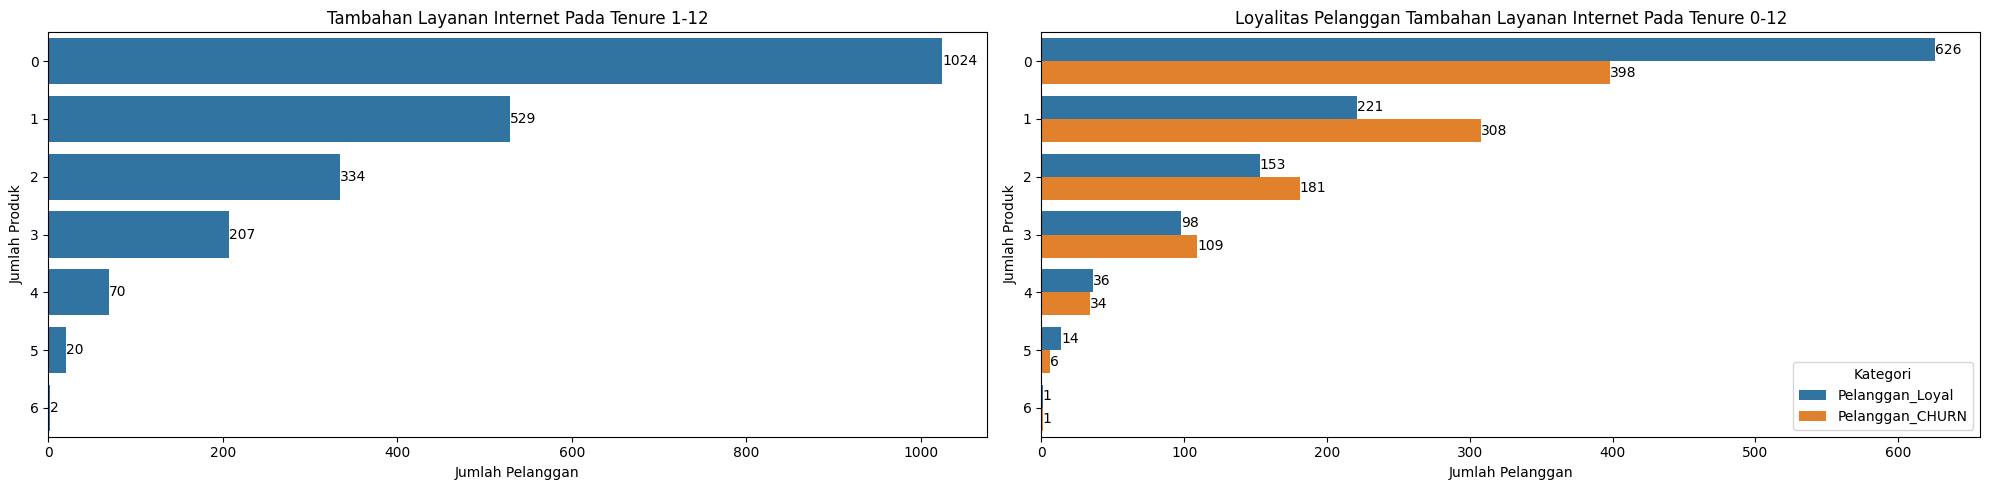

In [ ]:
# Melihat pada data Tenure 0-12 mengenai jumlah pelanggan Tambahan Layanan Internet
subc_cust = data[["Churn", "Tambahan Layanan Internet"]][data["Kategori Tenure"] == "Tenure 0-12"].groupby("Tambahan Layanan Internet").agg(
    Total_Pelanggan = ("Churn", "count"),
    Pelanggan_Loyal = ("Churn", lambda x: (x=="No").sum()),
    Pelanggan_CHURN = ("Churn", lambda x: (x=="Yes").sum())
).sort_values("Total_Pelanggan", ascending=False).reset_index()
display(subc_cust)

# Visualisasi
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(20,5))

sns.barplot(y=subc_cust['Tambahan Layanan Internet'], x=subc_cust['Total_Pelanggan'], ax=axes[0])
axes[0].bar_label(axes[0].containers[0], fontsize=10)
axes[0].set_title("Tambahan Layanan Internet Pada Tenure 1-12")
axes[0].set_xlabel("Jumlah Pelanggan")
axes[0].set_ylabel("Jumlah Produk")

visual_subc = subc_cust.melt(id_vars="Tambahan Layanan Internet", value_vars=["Pelanggan_Loyal", "Pelanggan_CHURN"],\
                             var_name="Kategori", value_name="Jumlah Pelanggan")
sns.barplot(data = visual_subc, y="Tambahan Layanan Internet", x="Jumlah Pelanggan", hue="Kategori", ax=axes[1])
axes[1].bar_label(axes[1].containers[0], fontsize=10)
axes[1].bar_label(axes[1].containers[1], fontsize=10)
axes[1].set_title("Loyalitas Pelanggan Tambahan Layanan Internet Pada Tenure 0-12")
axes[1].set_xlabel("Jumlah Pelanggan")
axes[1].set_ylabel("Jumlah Produk")

plt.tight_layout()
plt.show()

In [ ]:
# Melihat rata-rata total charge per tenure
data[['TotalCharges', "Kategori Tenure"]].groupby("Kategori Tenure").mean().sort_values("TotalCharges", ascending=False)

,TotalCharges
Kategori Tenure,
Tenure >60,5180.669829
Tenure 49-60,3848.132572
Tenure 37-48,2827.473163
Tenure 25-36,1990.199279
Tenure 13-24,1126.257520
Tenure 0-12,275.229597


In [ ]:
# Melihat rata-rata monthly charge per tenure
data[['MonthlyCharges', "Kategori Tenure"]].groupby("Kategori Tenure").mean().sort_values("MonthlyCharges", ascending=False)

,MonthlyCharges
Kategori Tenure,
Tenure >60,75.952701
Tenure 49-60,70.550781
Tenure 37-48,66.318241
Tenure 25-36,65.575481
Tenure 13-24,61.357275
Tenure 0-12,56.097781


In [ ]:
# Membandingkan rata-rata MonthlyCharges per tenure dengan persebaran pelanggan per tenure
display(
    data[['MonthlyCharges', "Kategori Tenure"]].groupby("Kategori Tenure").mean().sort_values("MonthlyCharges", ascending=False),
    pd.crosstab(data["Kategori Tenure"], data['Tambahan Layanan Internet'], normalize='index') * 100
)

,MonthlyCharges
Kategori Tenure,
Tenure >60,75.952701
Tenure 49-60,70.550781
Tenure 37-48,66.318241
Tenure 25-36,65.575481
Tenure 13-24,61.357275
Tenure 0-12,56.097781


Tambahan Layanan Internet,0,1,2,3,4,5,6
Kategori Tenure,,,,,,,
Tenure 0-12,46.843550,24.199451,15.279048,9.469350,3.202196,0.914913,0.091491
Tenure 13-24,32.128906,17.968750,22.460938,16.894531,7.812500,2.343750,0.390625
Tenure 25-36,25.841346,13.701923,21.153846,19.711538,11.658654,6.850962,1.081731
Tenure 37-48,24.934383,8.923885,14.435696,23.753281,17.585302,8.530184,1.837270
Tenure 49-60,21.754808,5.288462,11.538462,26.081731,19.951923,12.259615,3.125000
Tenure >60,19.900498,1.918977,6.183369,12.508884,21.677328,21.535181,16.275764


In [ ]:
# Melihat tambahan layanan internet StreamingMovies dan StreamingTV berdasarkan kategori tenure
stream_all = data[["StreamingMovies", "StreamingTV", "Kategori Tenure"]].groupby("Kategori Tenure").agg(
    Pelanggan_Movies = ("StreamingMovies", lambda x: (x=="Yes").sum()),
    Pelanggan_TV = ("StreamingTV", lambda x: (x=="Yes").sum())
  ).sort_values("Kategori Tenure", ascending=False).reset_index()
stream_all

stream_all["Pelanggan_Movies(%)"] = stream_all['Pelanggan_Movies'] / stream_all['Pelanggan_Movies'].sum() * 100
stream_all["Pelanggan_TV(%)"] = stream_all['Pelanggan_TV'] / stream_all['Pelanggan_TV'].sum() * 100

stream_churn = demochurn[["StreamingMovies", "StreamingTV", "Kategori Tenure"]].groupby("Kategori Tenure").agg(
    Pelanggan_Movies = ("StreamingMovies", lambda x: (x=="Yes").sum()),
    Pelanggan_TV = ("StreamingTV", lambda x: (x=="Yes").sum())
  ).sort_values("Kategori Tenure", ascending=False).reset_index()
stream_churn

stream_churn["Pelanggan_Movies(%)"] = stream_churn['Pelanggan_Movies'] / stream_churn['Pelanggan_Movies'].sum() * 100
stream_churn["Pelanggan_TV(%)"] = stream_churn['Pelanggan_TV'] / stream_churn['Pelanggan_TV'].sum() * 100

print("Tabel Pelanggan Layanan Tambahan Streaming Movies dan TV")
display(stream_all)

print("\nTabel Pelanggan CHURN Pada Layanan Tambahan Streaming Movies dan TV")
display(stream_churn)

Tabel Pelanggan Layanan Tambahan Streaming Movies dan TV


,Kategori Tenure,Pelanggan_Movies,Pelanggan_TV,Pelanggan_Movies(%),Pelanggan_TV(%)
0,Tenure >60,831,812,30.417277,29.996306
1,Tenure 49-60,419,417,15.336750,15.404507
2,Tenure 37-48,325,332,11.896047,12.264499
3,Tenure 25-36,330,322,12.079063,11.895087
4,Tenure 13-24,332,333,12.152269,12.301441
5,Tenure 0-12,495,491,18.118594,18.138160



Tabel Pelanggan CHURN Pada Layanan Tambahan Streaming Movies dan TV


,Kategori Tenure,Pelanggan_Movies,Pelanggan_TV,Pelanggan_Movies(%),Pelanggan_TV(%)
0,Tenure >60,79,78,9.657702,9.582310
1,Tenure 49-60,88,90,10.757946,11.056511
2,Tenure 37-48,89,90,10.880196,11.056511
3,Tenure 25-36,106,97,12.958435,11.916462
4,Tenure 13-24,146,146,17.848411,17.936118
5,Tenure 0-12,310,313,37.897311,38.452088


**Hasil Yang Ditemukan**

- **Kategori Tenure 0-12** (pelanggan baru) memiliki **jumlah pelanggan terbanyak dan CHURN terbesar**

- **Pelanggan baru** cenderung **hanya** menggunakan **Layanan Telepon**

- Jika menggunakan **produk Layanan Internet**, **pelanggan baru cenderung** hanya **menggunakan 1 atau 2 produk tambahan saja**.

- Untuk penggunaan **produk Layanan Internet** pada **pelanggan baru**, jumlah **pelanggan CHURN lebih banyak** dibandingkan dengan pelanggan yang Loyal.

- **Kategori Tenure 0-12** (pelanggan baru) memiliki** rata-rata revenue bulanan terkecil** dikarekan faktor-faktor di atas

# **KESIMPULAN DAN REKOMENDASI**

## **Kesimpulan**

**A. Demografi Pelanggan *Churn***

Pelanggan yang melakukan *churn* umumnya memiliki kebiasaan sebagai berikut.
  * Belum memiliki pasangan
  * Tidak memiliki tanggungan
  * Pelanggan baru (tenure 0 - 12 bulan)
  * Umumnya adalah orang muda dikarenakan mayoritas pelanggan adalah orang muda
  * Jika melihat lansia saja, churn pada umur ini sangat besar

**B. Tingkat Churn**

Tingkat churn pelanggan pada data adalah **26.54%**. Ini berarti, perusahaan berada jauh di atas standar churn industri perusahaan telco yang baik yaitu *10 - 15%* (Forbes 2015 Industry Review).

**C. Produk Dengan Performa Buruk**
* Pada produk utama, Layanan Telepon dan Fiber Optic (Layanan Internet) merupakan layanan dengan jumlah pelanggan terbanyak tetapi memiliki tingkat *churn* terbesar. Akibatnya layanan ini juga memberikan revenue loss terbesar.
* Pada tambahan Layanan Internet, StreamingMovies dan StreamingTV merupakan produk dengan jumlah pelanggan terbanyak tetapi memiliki tingkat churn terbesar. Hal ini dikarenakan banyak pelanggan baru (Tenure 0-12 bulan) yang hanya menggunakan produk ini saja sedangkan pelanggan baru sering melakukan *churn*.

**D. Metode Pembayaran dan Kontrak Layanan Buruk**
* Metode pembayaran berupa electronic check adalah metode pembayaran dengan jumlah pelanggan terbesar tetapi memiliki *churn* terbesar
* Kontrak layanan berupa Month-to-month adalah kontrak dengan jumlah pelanggan terbesar tetapi memiliki *churn* terbesar.

## **Rekomendasi**

**A. Demografi Pelanggan *Churn***
* Untuk mempertahankan pelanggan baru, terlebih lagi pelanggan yang masih muda, pastikan produk-produk yang ditawarkan memiliki harga yang bersaing dengan kualitas yang sebanding harga. Usahakan juga pelanggan-pelanggan ini mengambil jenis kontrak One Year atau Two Year. Berikan juga variasi tingkat produk sesuai kebutuhan, misalkan versi premium, gamer, lite dan lain-lain.

**B. Penurunan Tingkat *Churn***
* Gunakan target penurunan tingkat *churn* menjadi minimal 15% dari tingkat sekarang sebagai patokan keberhasilan penerapan rekomendasi solusi yang diberikan.

**C. Produk Dengan Performa Buruk**
* Untuk Layanan Telepon harga layanan ini dapat diturunkan, dikarenakan pada masa ini, komunikasi jarak jauh sudah lebih sering melalui media internet seperti Whatsapp, Discord, dan lain-lain. Selain itu, untuk Layanan Telepon, perusahaan dapat mencoba mengubah target pelanggan dari B2C menjadi B2B.
* Untuk Fiber Optic (Layanan Internet), lakukan evaluasi pelanggan untuk menemukan ketidakpuasan pelanggan pada produk ini. Selain itu, pastikan produk memiliki stabilitas koneksi yang baik (hal yang sangat dicari pelanggan muda). Perusahaan juga dapat menerapkan variasi tingkat internet sesuai kebutuhan, misalkan versi gamer, family, business, dan lain-lain.
* Pada StreamingMovies dan StreamingTV, lakukan riset pasar untuk film/saluran yang sesuai dengan demografi pelanggan perusahaan (orang muda). Selain itu, analisis apakah ada kesulitan pengaksesan layanan StreamingMovies dan StreamingTV dari sisi pengguna.

**D. Metode Pembayaran dan Kontrak Layanan Buruk**
* Electronic check sebagai alat pembayaran masih sangat relevan di Negara Amerika. Perlu dilakukan pengecekan kembali apakah ada masalah pada proses pembayaran ini dari sisi perusahaan atau kesulitan dari sisi pengguna.
* Untuk pengguna kontrak Month-to-month, tawarkan *upgrade* ke kontrak One Year atau Two Year dengan skema hanya membayar 9 bulan untuk berlangganan 12 bulan (kontrak One Year) atau skema hanya membayar 19 bulan untuk berlangganan 24 bulan (kontrak Two Year). Untuk jumlah bulan yang perlu dibayar dan diberikan gratis kepada pelanggan, dapat dipertimbangkan kembali dan disesuaikan oleh perusahaan.
